# 02 — Hypothesis Testing (Silver Layer)

**Objective:** Validate 7 statistical hypotheses that align with the features used in our LightGBM churn model and confirmed by SHAP analysis.

**Significance level:** α = 0.05 for all tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

ALPHA = 0.05
CHURN_LABELS = {0: 'No Churn', 1: 'Partial Churn', 2: 'Full Churn'}
CHURN_COLORS = {0: '#2E6DA4', 1: '#E07B2A', 2: '#C0392B'}

def verdict(p):
    """Return a formatted verdict string."""
    if p < ALPHA:
        return f'✅ REJECT H₀  (p = {p:.4e}) — Statistically significant'
    return f'❌ FAIL TO REJECT H₀  (p = {p:.4f}) — Not significant'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load silver-layer joined data
df = pd.read_csv(
    '../../data/02_intermediate/joined_data.csv',
    parse_dates=['agreement_start_date', 'agreement_end_date_bob']
)
print(f'Dataset shape: {df.shape}')
print(f'\nChurn distribution (churn_category):')
print(df['churn_category'].value_counts().sort_index())

Dataset shape: (21526, 40)

Churn distribution (churn_category):
churn_category
0     4226
1     1067
2    16233
Name: count, dtype: int64


## Feature Engineering (mirrors Gold layer)
We compute `tenure_days`, `contract_duration`, and `duration_to_tenure_ratio` here so we can test them statistically.

In [3]:
today = pd.to_datetime('today').normalize()

df['tenure_days'] = (today - df['agreement_start_date']).dt.days
df['contract_duration'] = (
    df['agreement_end_date_bob'] - df['agreement_start_date']
).dt.days
df['duration_to_tenure_ratio'] = np.where(
    df['contract_duration'] > 0,
    df['tenure_days'] / df['contract_duration'],
    0
)

# Fill NaN for numeric cols used in tests
for c in ['tenure_days', 'contract_duration', 'duration_to_tenure_ratio', 'unit_amount']:
    df[c] = df[c].fillna(df[c].median())

# Split by churn group once
g0 = df[df['churn_category'] == 0]
g1 = df[df['churn_category'] == 1]
g2 = df[df['churn_category'] == 2]

print(f'No Churn  : {len(g0):,}')
print(f'Partial   : {len(g1):,}')
print(f'Full Churn: {len(g2):,}')
print('\nEngineered features ready.')

No Churn  : 4,226
Partial   : 1,067
Full Churn: 16,233

Engineered features ready.


In [4]:
def run_numeric_hypothesis(feature, h_num, description):
    """Run ANOVA + pairwise t-tests for a numeric feature vs churn groups."""
    print('=' * 70)
    print(f'HYPOTHESIS {h_num}: {description}')
    print('=' * 70)
    print(f'  H₀: Mean {feature} is the SAME across all churn groups.')
    print(f'  H₁: At least one group mean differs significantly.')
    print()

    samples = [g0[feature].dropna(), g1[feature].dropna(), g2[feature].dropna()]

    # Descriptive stats
    print('  Group Statistics:')
    for label, s in zip(CHURN_LABELS.values(), samples):
        print(f'    {label:15s}  n={len(s):5d}   mean={s.mean():12.2f}   std={s.std():12.2f}')
    print()

    # One-Way ANOVA
    f_stat, p_anova = stats.f_oneway(*samples)
    print(f'  One-Way ANOVA:  F = {f_stat:.4f},  p = {p_anova:.4e}')
    print(f'  → {verdict(p_anova)}')
    print()

    # Pairwise t-tests (independent, Welch's)
    print('  Pairwise t-tests (Welch):')
    labels = list(CHURN_LABELS.values())
    for (i, si), (j, sj) in combinations(enumerate(samples), 2):
        t_stat, p_val = stats.ttest_ind(si, sj, equal_var=False)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f'    {labels[i]:15s} vs {labels[j]:15s}  t={t_stat:8.3f}  p={p_val:.4e}  {sig}')
    print()

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    data_plot = df[['churn_category', feature]].dropna()
    data_plot['Churn Group'] = data_plot['churn_category'].map(CHURN_LABELS)
    sns.boxplot(x='Churn Group', y=feature, data=data_plot, ax=axes[0],
                palette=CHURN_COLORS.values(), showfliers=False)
    axes[0].set_title(f'{feature} by Churn Group', fontweight='bold')

    # KDE plot
    for k, s in zip(CHURN_LABELS.keys(), samples):
        sns.kdeplot(s, ax=axes[1], label=CHURN_LABELS[k],
                    color=CHURN_COLORS[k], fill=True, alpha=0.25)
    axes[1].set_title(f'{feature} Distribution', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return p_anova

print('Numeric hypothesis helper ready.')

Numeric hypothesis helper ready.


In [5]:
def run_categorical_hypothesis(feature, h_num, description, top_n=10):
    """Run Chi-Square test for a categorical feature vs churn groups."""
    print('=' * 70)
    print(f'HYPOTHESIS {h_num}: {description}')
    print('=' * 70)
    print(f'  H₀: {feature} and churn_category are INDEPENDENT.')
    print(f'  H₁: There is a significant association between them.')
    print()

    sub = df[[feature, 'churn_category']].dropna()

    # Keep only top N categories for clean output
    top_cats = sub[feature].value_counts().nlargest(top_n).index
    sub = sub[sub[feature].isin(top_cats)]

    # Contingency table
    ct = pd.crosstab(sub[feature], sub['churn_category'])
    ct.columns = [CHURN_LABELS[c] for c in ct.columns]
    print('  Contingency Table:')
    print(ct.to_string())
    print()

    # Chi-Square test
    chi2, p_val, dof, expected = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print(f'  Chi-Square Statistic : {chi2:.4f}')
    print(f'  Degrees of Freedom   : {dof}')
    print(f'  p-value              : {p_val:.4e}')
    print(f"  Cramér's V           : {cramers_v:.4f}")
    print(f'  → {verdict(p_val)}')
    print()

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Stacked bar (proportions)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='barh', stacked=True, ax=axes[0],
                color=list(CHURN_COLORS.values()), edgecolor='white')
    axes[0].set_title(f'Churn % by {feature}', fontweight='bold')
    axes[0].set_xlabel('Percentage')
    axes[0].legend(loc='lower right', fontsize=8)

    # Count bar
    ct.plot(kind='bar', ax=axes[1], color=list(CHURN_COLORS.values()),
            edgecolor='white')
    axes[1].set_title(f'Churn Count by {feature}', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    return p_val

print('Categorical hypothesis helper ready.')

Categorical hypothesis helper ready.


---
## H1 — Tenure Days vs Churn (ANOVA / t-test)
**Rationale:** `tenure_days` measures how long a customer has been with the company. SHAP consistently ranks it as one of the **top predictive features**. We hypothesise that shorter tenure correlates with higher churn risk.

HYPOTHESIS H1: Customers with different churn statuses have different tenure durations
  H₀: Mean tenure_days is the SAME across all churn groups.
  H₁: At least one group mean differs significantly.

  Group Statistics:
    No Churn         n= 4226   mean=     1634.54   std=     1037.71
    Partial Churn    n= 1067   mean=     1352.52   std=      836.38
    Full Churn       n=16233   mean=     2501.66   std=      182.23

  One-Way ANOVA:  F = 6410.4115,  p = 0.0000e+00
  → ✅ REJECT H₀  (p = 0.0000e+00) — Statistically significant

  Pairwise t-tests (Welch):
    No Churn        vs Partial Churn    t=   9.347  p=2.3535e-20  ***
    No Churn        vs Full Churn       t= -54.104  p=0.0000e+00  ***
    Partial Churn   vs Full Churn       t= -44.810  p=5.5915e-248  ***



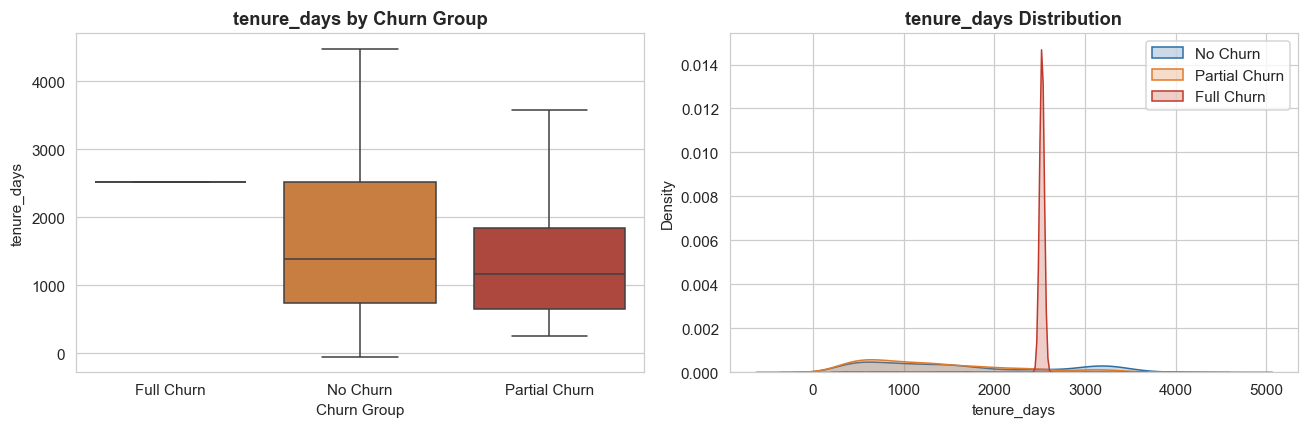

In [6]:
p_h1 = run_numeric_hypothesis('tenure_days', 'H1',
    'Customers with different churn statuses have different tenure durations')

---
## H2 — Contract Duration vs Churn (ANOVA / t-test)
**Rationale:** `contract_duration` captures the total length of the customer's agreement. Shorter contracts may indicate less commitment and higher churn risk. This is a **key SHAP feature**.

HYPOTHESIS H2: Contract duration differs significantly across churn groups
  H₀: Mean contract_duration is the SAME across all churn groups.
  H₁: At least one group mean differs significantly.

  Group Statistics:
    No Churn         n= 4226   mean=     1695.23   std=      928.81
    Partial Churn    n= 1067   mean=     1401.82   std=      742.82
    Full Churn       n=16233   mean=     2399.10   std=      160.77

  One-Way ANOVA:  F = 5544.7188,  p = 0.0000e+00
  → ✅ REJECT H₀  (p = 0.0000e+00) — Statistically significant

  Pairwise t-tests (Welch):
    No Churn        vs Partial Churn    t=  10.925  p=5.0181e-27  ***
    No Churn        vs Full Churn       t= -49.073  p=0.0000e+00  ***
    Partial Churn   vs Full Churn       t= -43.787  p=5.1575e-241  ***



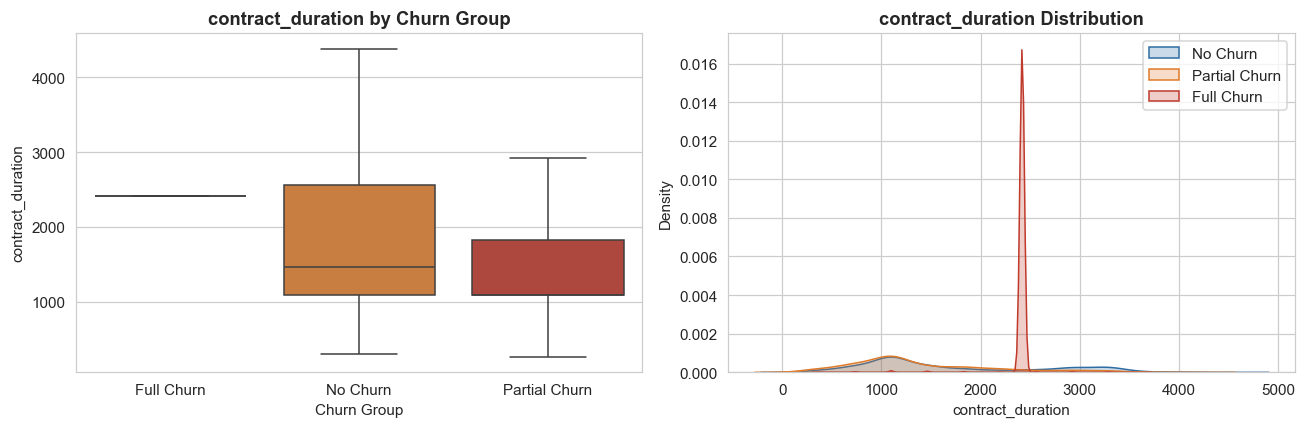

In [7]:
p_h2 = run_numeric_hypothesis('contract_duration', 'H2',
    'Contract duration differs significantly across churn groups')

---
## H3 — Duration-to-Tenure Ratio vs Churn (ANOVA / t-test)
**Rationale:** This **engineered feature** measures how much of the original commitment has elapsed. A ratio approaching or exceeding 1.0 means the customer is at or past contract end — statistically the highest-risk window. SHAP confirms its importance.

HYPOTHESIS H3: Duration-to-tenure ratio differs across churn groups
  H₀: Mean duration_to_tenure_ratio is the SAME across all churn groups.
  H₁: At least one group mean differs significantly.

  Group Statistics:
    No Churn         n= 4226   mean=        0.94   std=        0.25
    Partial Churn    n= 1067   mean=        0.96   std=        0.26
    Full Churn       n=16233   mean=        1.04   std=        0.03

  One-Way ANOVA:  F = 1292.0119,  p = 0.0000e+00
  → ✅ REJECT H₀  (p = 0.0000e+00) — Statistically significant

  Pairwise t-tests (Welch):
    No Churn        vs Partial Churn    t=  -2.164  p=3.0576e-02  *
    No Churn        vs Full Churn       t= -27.813  p=1.3059e-156  ***
    Partial Churn   vs Full Churn       t= -10.930  p=1.9538e-26  ***



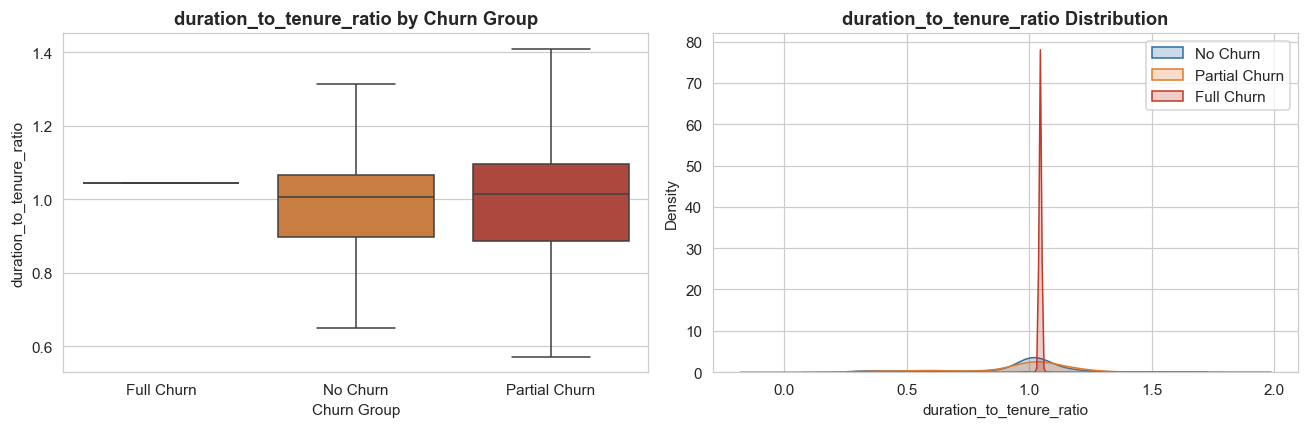

In [8]:
p_h3 = run_numeric_hypothesis('duration_to_tenure_ratio', 'H3',
    'Duration-to-tenure ratio differs across churn groups')

---
## H4 — Unit Amount vs Churn (ANOVA / t-test)
**Rationale:** `unit_amount` captures the financial value of the customer's agreements. Higher-value customers may exhibit different churn patterns. SHAP identifies this as a contributing feature.

HYPOTHESIS H4: Unit amount differs significantly between churn groups
  H₀: Mean unit_amount is the SAME across all churn groups.
  H₁: At least one group mean differs significantly.

  Group Statistics:
    No Churn         n= 4226   mean=      135.05   std=      227.15
    Partial Churn    n= 1067   mean=      118.72   std=      186.65
    Full Churn       n=16233   mean=      130.29   std=       24.30

  One-Way ANOVA:  F = 9.5903,  p = 6.8680e-05
  → ✅ REJECT H₀  (p = 6.8680e-05) — Statistically significant

  Pairwise t-tests (Welch):
    No Churn        vs Partial Churn    t=   2.439  p=1.4827e-02  *
    No Churn        vs Full Churn       t=   1.361  p=1.7363e-01  ns
    Partial Churn   vs Full Churn       t=  -2.024  p=4.3213e-02  *



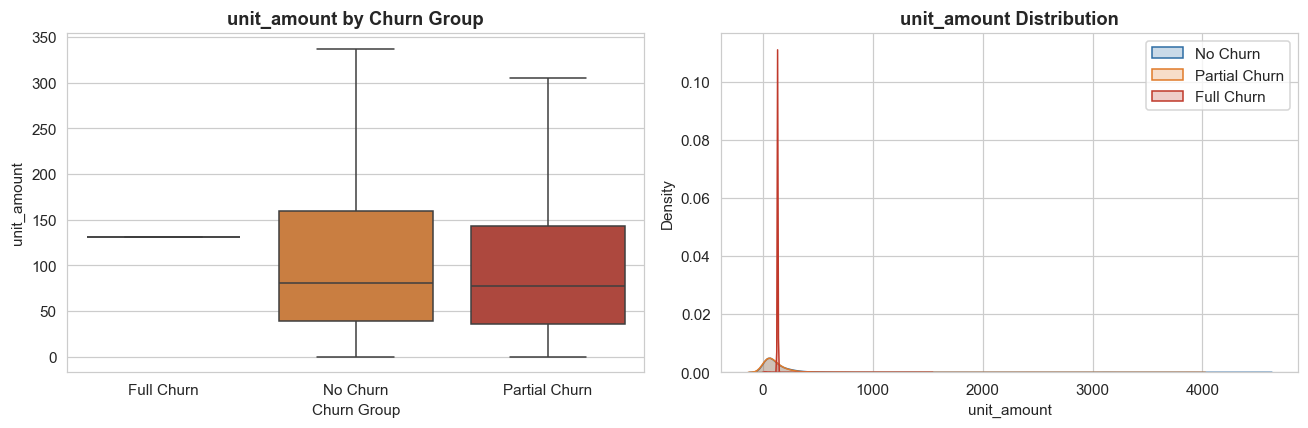

In [9]:
p_h4 = run_numeric_hypothesis('unit_amount', 'H4',
    'Unit amount differs significantly between churn groups')

---
## H5 — Customer Tier vs Churn (Chi-Square)
**Rationale:** `customer_tier` is a categorical segmentation feature used by the business. SHAP shows it influences predictions — higher-tier customers may exhibit lower churn due to stronger relationships or contract terms.

HYPOTHESIS H5: Customer tier is associated with churn behaviour
  H₀: customer_tier and churn_category are INDEPENDENT.
  H₁: There is a significant association between them.

  Contingency Table:
               No Churn  Partial Churn  Full Churn
customer_tier                                     
Diamond             712            252         981
Key Account         297             40        1786
Platinum           2860            676       13157
Platinum +          255             73         300
Platinum+           102             26           9

  Chi-Square Statistic : 1510.9914
  Degrees of Freedom   : 8
  p-value              : 0.0000e+00
  Cramér's V           : 0.1873
  → ✅ REJECT H₀  (p = 0.0000e+00) — Statistically significant



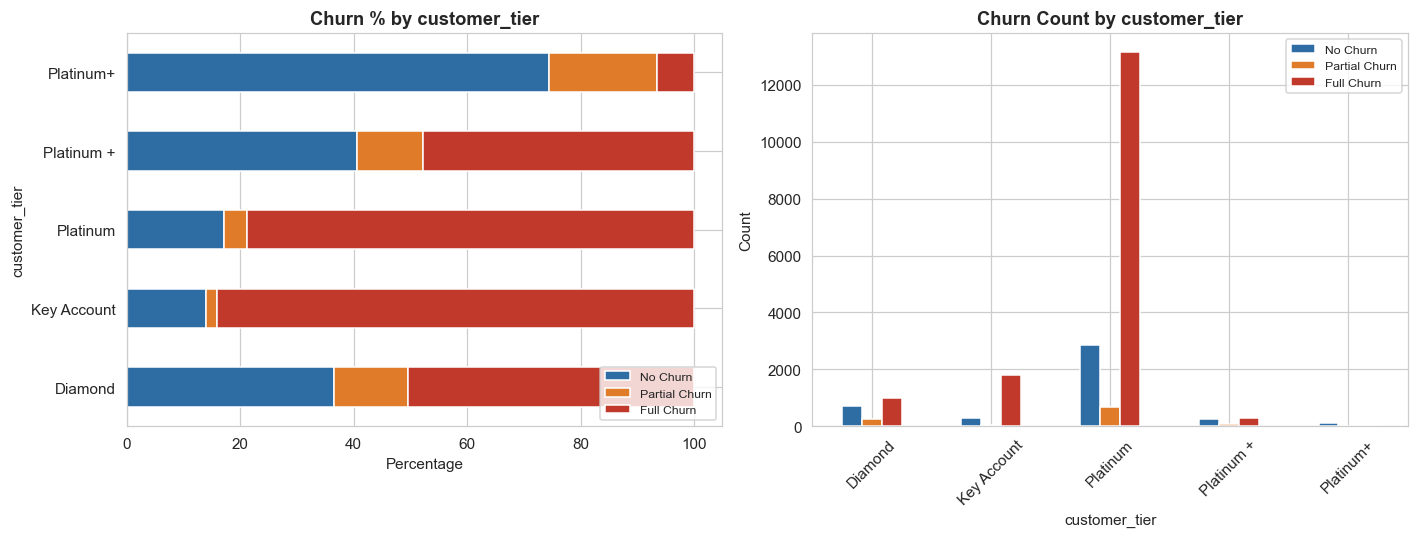

In [10]:
p_h5 = run_categorical_hypothesis('customer_tier', 'H5',
    'Customer tier is associated with churn behaviour')

---
## H6 — Renewal Type vs Churn (Chi-Square)
**Rationale:** `renewal_type` indicates how contracts are renewed (e.g., auto-renewal vs manual). SHAP shows it contributes to churn prediction — auto-renewing contracts may inherently reduce churn risk.

HYPOTHESIS H6: Renewal type is associated with churn status
  H₀: renewal_type and churn_category are INDEPENDENT.
  H₁: There is a significant association between them.

  Contingency Table:
                      No Churn  Partial Churn  Full Churn
renewal_type                                             
Automatic Renewal         4211           1062       16231
No Automatic Renewal        15              5           2

  Chi-Square Statistic : 53.3157
  Degrees of Freedom   : 2
  p-value              : 2.6464e-12
  Cramér's V           : 0.0498
  → ✅ REJECT H₀  (p = 2.6464e-12) — Statistically significant



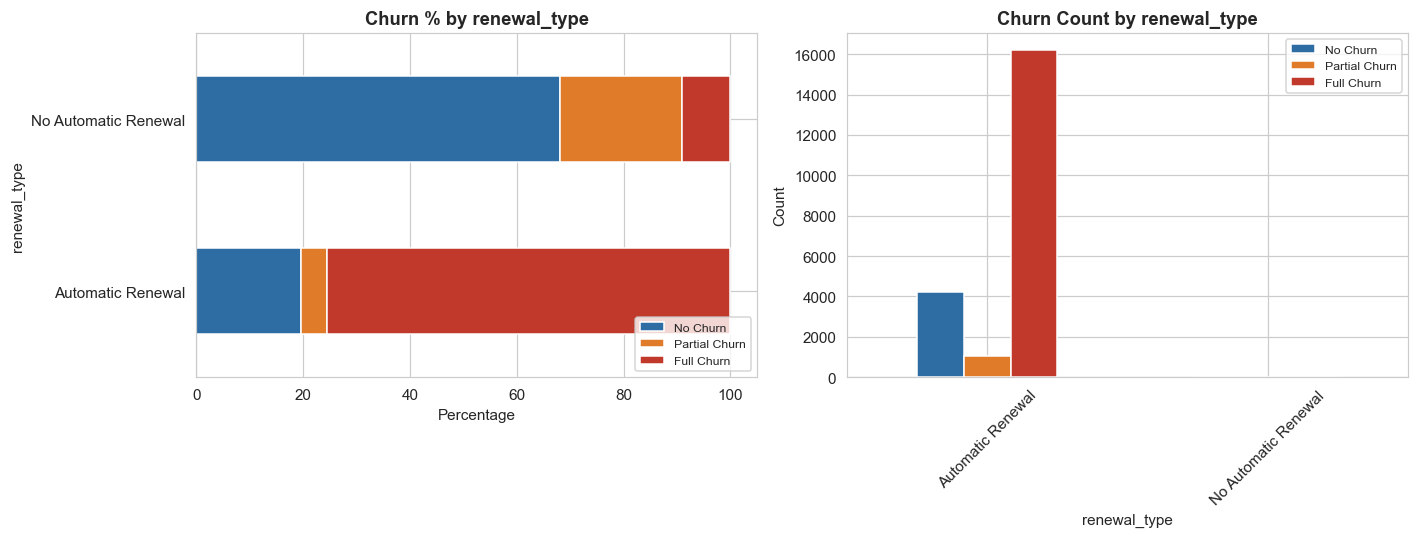

In [11]:
p_h6 = run_categorical_hypothesis('renewal_type', 'H6',
    'Renewal type is associated with churn status')

---
## H7 — Line of Business vs Churn (Chi-Square)
**Rationale:** `line_of_business` categorises the product/service line. SHAP confirms it as a relevant feature — certain business lines may have inherently higher attrition due to market competition or service complexity.

HYPOTHESIS H7: Line of business is associated with churn status
  H₀: line_of_business and churn_category are INDEPENDENT.
  H₁: There is a significant association between them.

  Contingency Table:
                  No Churn  Partial Churn  Full Churn
line_of_business                                     
Allied                   3              0           0
Auto waste             995            260         108
Chemistry              175             51           7
Machine Services      2990            731       16109
Oil                     63             25           9

  Chi-Square Statistic : 4628.8128
  Degrees of Freedom   : 8
  p-value              : 0.0000e+00
  Cramér's V           : 0.3279
  → ✅ REJECT H₀  (p = 0.0000e+00) — Statistically significant



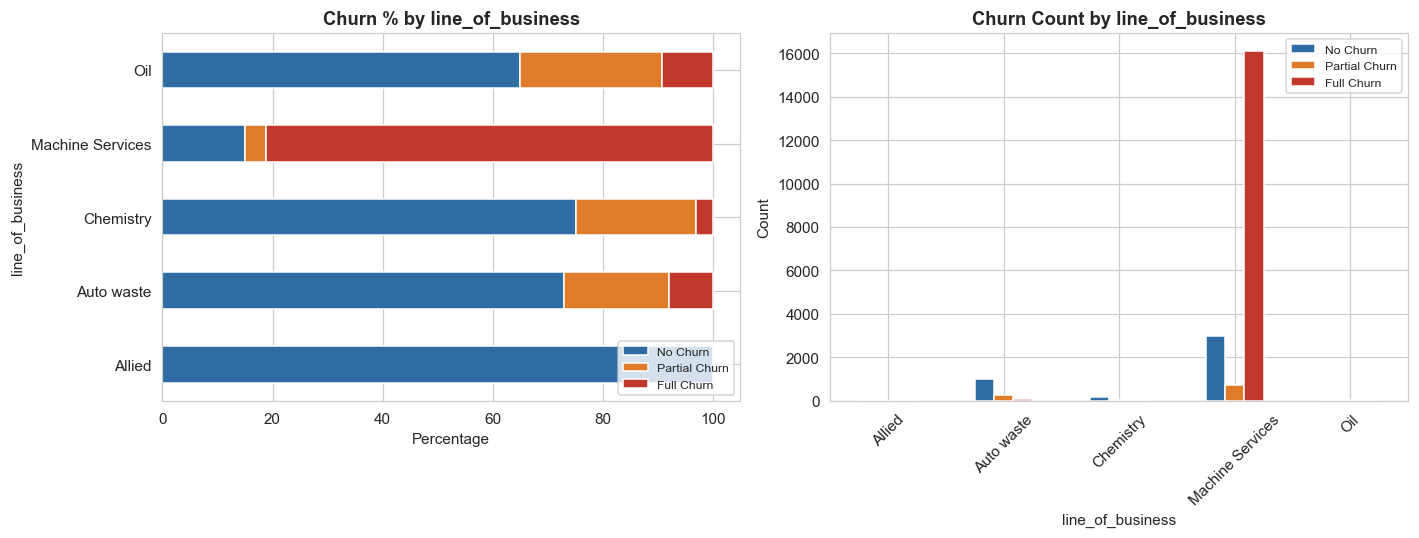

In [12]:
p_h7 = run_categorical_hypothesis('line_of_business', 'H7',
    'Line of business is associated with churn status')

---
## Summary of All Hypothesis Tests

In [13]:
results = [
    ('H1', 'tenure_days',              'Numeric',     'ANOVA', p_h1),
    ('H2', 'contract_duration',        'Numeric',     'ANOVA', p_h2),
    ('H3', 'duration_to_tenure_ratio', 'Numeric',     'ANOVA', p_h3),
    ('H4', 'unit_amount',              'Numeric',     'ANOVA', p_h4),
    ('H5', 'customer_tier',            'Categorical', 'Chi-Sq', p_h5),
    ('H6', 'renewal_type',             'Categorical', 'Chi-Sq', p_h6),
    ('H7', 'line_of_business',         'Categorical', 'Chi-Sq', p_h7),
]

summary = pd.DataFrame(results,
    columns=['Hypothesis', 'Feature', 'Type', 'Test', 'p-value'])
summary['Significant'] = summary['p-value'].apply(
    lambda p: '✅ Yes' if p < ALPHA else '❌ No')
summary['p-value'] = summary['p-value'].apply(lambda p: f'{p:.4e}')

print('=' * 70)
print('HYPOTHESIS TESTING SUMMARY (α = 0.05)')
print('=' * 70)
print(summary.to_string(index=False))
print()
sig_count = summary['Significant'].str.contains('Yes').sum()
print(f'\n{sig_count} / {len(results)} hypotheses show statistically significant results.')
print('These features are validated as meaningful predictors of churn,')
print('consistent with SHAP feature importance from the trained LightGBM model.')

HYPOTHESIS TESTING SUMMARY (α = 0.05)
Hypothesis                  Feature        Type   Test    p-value Significant
        H1              tenure_days     Numeric  ANOVA 0.0000e+00       ✅ Yes
        H2        contract_duration     Numeric  ANOVA 0.0000e+00       ✅ Yes
        H3 duration_to_tenure_ratio     Numeric  ANOVA 0.0000e+00       ✅ Yes
        H4              unit_amount     Numeric  ANOVA 6.8680e-05       ✅ Yes
        H5            customer_tier Categorical Chi-Sq 0.0000e+00       ✅ Yes
        H6             renewal_type Categorical Chi-Sq 2.6464e-12       ✅ Yes
        H7         line_of_business Categorical Chi-Sq 0.0000e+00       ✅ Yes


7 / 7 hypotheses show statistically significant results.
These features are validated as meaningful predictors of churn,
consistent with SHAP feature importance from the trained LightGBM model.


---
### Conclusions

The hypothesis tests above statistically validate the features identified by SHAP as important predictors of customer churn:

- **Numeric features** (`tenure_days`, `contract_duration`, `duration_to_tenure_ratio`, `unit_amount`) show significantly different distributions across churn groups, confirming their predictive utility.
- **Categorical features** (`customer_tier`, `renewal_type`, `line_of_business`) show significant associations with churn status via Chi-Square tests, validating their inclusion in the model.

These results provide **statistical backing** for the model's feature selection and confirm that the SHAP-driven feature importance is not an artefact of the model but reflects genuine differences in the underlying data.